In [1]:
import pandas as pd
import matplotlib.pyplot as plt

series = pd.read_parquet(
    "../data/processed/monthly_series_31.parquet"
)["y"]

series.head()

2022-02-01    2064
2022-03-01    1902
2022-04-01    2097
2022-05-01    2016
2022-06-01    1947
Name: y, dtype: int64

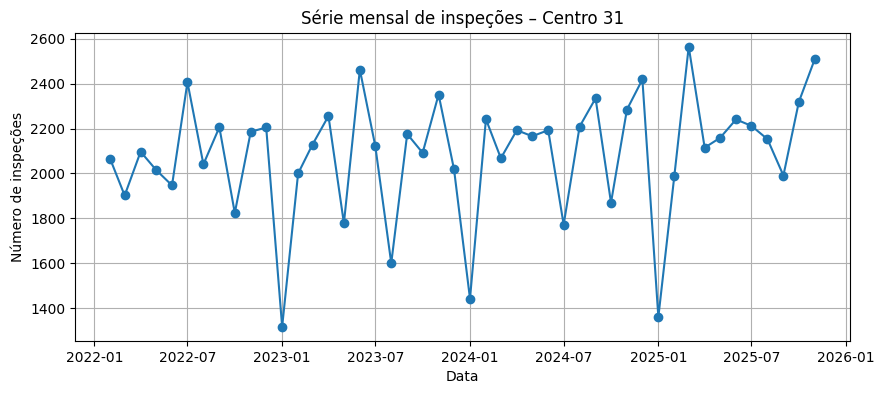

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(series, marker="o")
plt.title("Série mensal de inspeções – Centro 31")
plt.xlabel("Data")
plt.ylabel("Número de inspeções")
plt.grid(True)
plt.show()

In [3]:
series.describe()

count      46.000000
mean     2087.065217
std       273.241643
min      1317.000000
25%      1993.250000
50%      2141.000000
75%      2233.750000
max      2565.000000
Name: y, dtype: float64

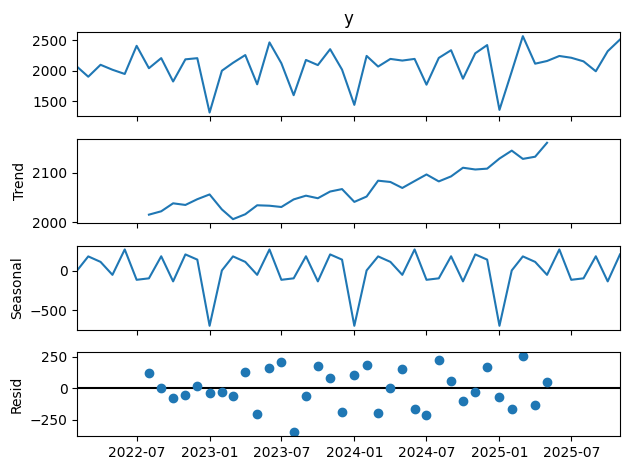

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    series,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()


In [5]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -6.982755710339409
p-value: 8.112486798015139e-10


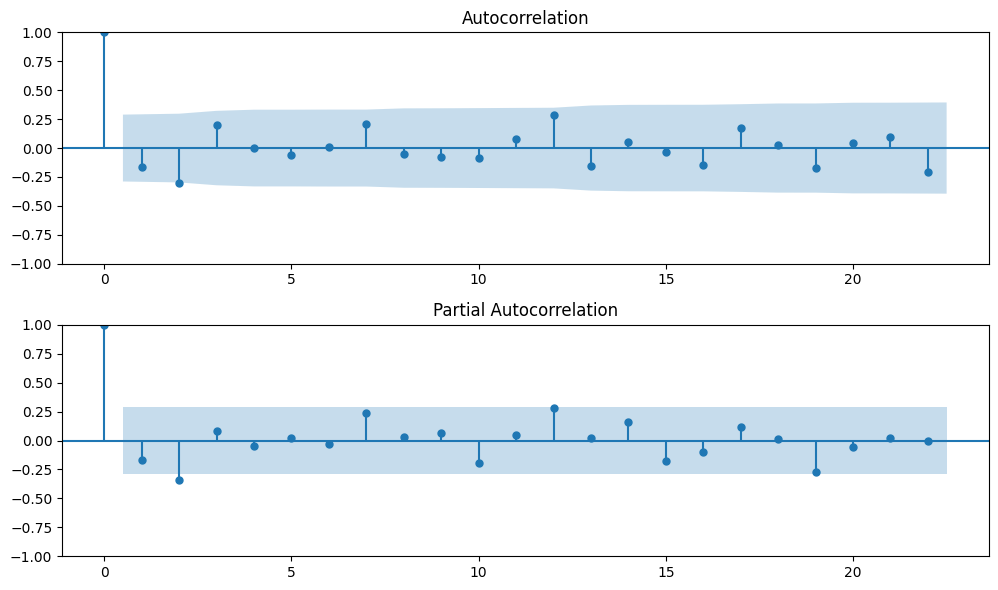

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=22, ax=ax[0])
plot_pacf(series, lags=22, ax=ax[1])

plt.tight_layout()
plt.show()


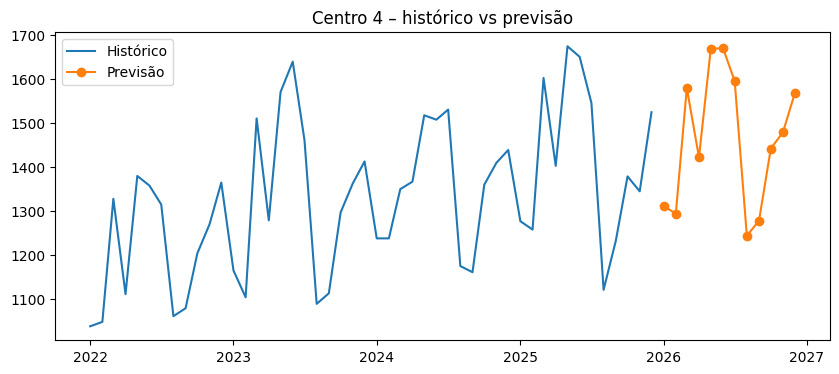

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.read_parquet("../data/processed/monthly_all_centers.parquet")
fcst = pd.read_parquet("../data/processed/forecast_monthly_all_centers.parquet")

center = 4

hist_c = hist[hist["CFGCENTROID"] == center]
fcst_c = fcst[fcst["CFGCENTROID"] == center]

plt.figure(figsize=(10,4))
plt.plot(hist_c["MONTH"], hist_c["y"], label="Histórico")
plt.plot(fcst_c["MONTH"], fcst_c["y_hat"], label="Previsão", marker="o")
plt.legend()
plt.title(f"Centro {center} – histórico vs previsão")
plt.show()


In [17]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# carregar série
df = pd.read_parquet("../data/processed/monthly_all_centers.parquet")
center = 31
series = df[df["CFGCENTROID"] == center].sort_values("MONTH")
y = series["y"].values

# split: último mês como teste
train, test = y[:-1], y[-1:]

# modelo
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# previsão 1 mês
y_hat = model.forecast(1)

# erros
mae = mean_absolute_error(test, y_hat)
rmse = np.sqrt(mean_squared_error(test, y_hat))

print(f"Centro {center} – backtest 1 mês")
print(f"Real: {test[0]:.0f}")
print(f"Previsto: {y_hat[0]:.0f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Centro 31 – backtest 1 mês
Real: 5404
Previsto: 5382
MAE: 21.80
RMSE: 21.80


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# garantir índice temporal
series = series.copy()
series.index = pd.to_datetime(series.index)

# STL
stl = STL(series, period=12, robust=True)
res = stl.fit()

# suavização APENAS para visualização
y_smooth = series.rolling(3, center=True).mean()
trend_smooth = res.trend.rolling(3, center=True).mean()
resid_smooth = res.resid.rolling(3, center=True).mean()

# perfil sazonal médio
seasonal = res.seasonal
seasonal_df = pd.DataFrame({
    "month": series.index.month,
    "seasonal": seasonal
})
seasonal_mean = seasonal_df.groupby("month")["seasonal"].mean()

# --- PLOT ---
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=False)

# Série original
axes[0].plot(y_smooth, color="tab:blue", linewidth=2)
axes[0].set_title("Série original (suavizada para visualização)")
axes[0].grid(alpha=0.3)

# Tendência
axes[1].plot(trend_smooth, color="tab:orange", linewidth=2)
axes[1].set_title("Tendência (STL)")
axes[1].grid(alpha=0.3)

# Perfil sazonal médio
months = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
axes[2].bar(months, seasonal_mean.values, color="seagreen")
axes[2].set_title("Perfil sazonal médio (STL)")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].grid(axis="y", alpha=0.3)

# Resíduos
sigma = resid_smooth.std()
axes[3].plot(resid_smooth, color="gray", linewidth=1.5)
axes[3].axhline(2*sigma, color="red", linestyle="--", label="+2σ")
axes[3].axhline(-2*sigma, color="blue", linestyle="--", label="-2σ")
axes[3].set_title("Resíduos e outliers (±2σ)")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()



TypeError: float() argument must be a string or a real number, not 'Timestamp'

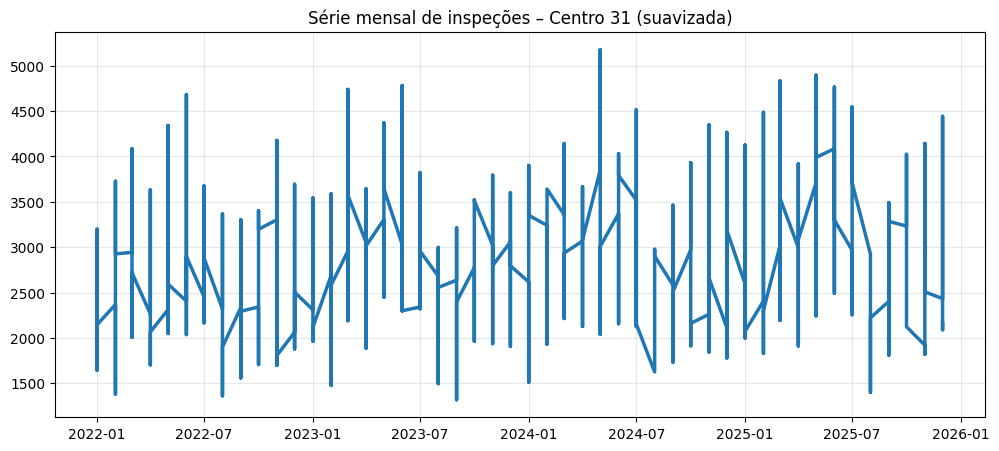

In [ ]:
series_smooth = series.rolling(3, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(series_smooth.index, series_smooth.values, linewidth=2.5)
plt.title("Série mensal de inspeções – Centro 31 (suavizada)")
plt.grid(alpha=0.3)
plt.show()


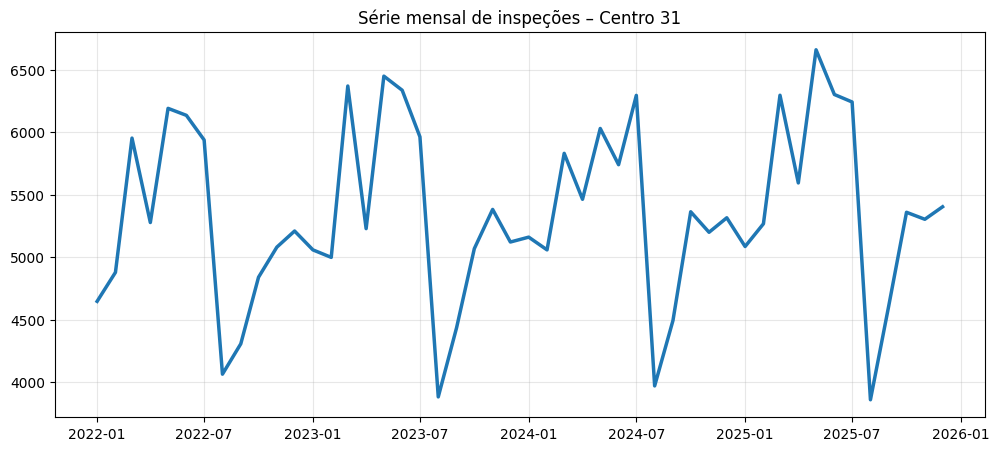

In [ ]:
center_id = 31

series = (
    df[df["CFGCENTROID"] == center_id]
    .set_index("MONTH")["y"]
    .sort_index()
)
plt.figure(figsize=(12,5))
plt.plot(series.index, series.values, linewidth=2.5)
plt.title(f"Série mensal de inspeções – Centro {center_id}")
plt.grid(alpha=0.3)
plt.show()


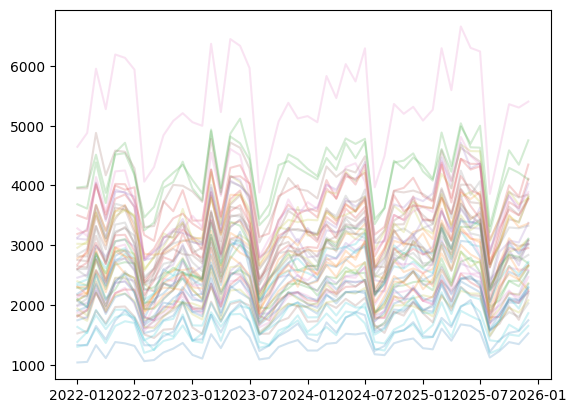

In [ ]:
for cid, g in df.groupby("CFGCENTROID"):
    plt.plot(g["MONTH"], g["y"], alpha=0.2)


In [ ]:
df["CFGCENTROID"].nunique()


51

In [28]:
import pandas as pd

df_plot = pd.read_parquet(
    "../data/processed/backtest_plot_all_centers.parquet"
)
